In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data    # data has actual predictor values
y = data.target  # target has classes we want to predict

print(X.shape)
print(data.target_names)

(569, 30)
['malignant' 'benign']


In [ ]:
# 569 → observations/samples
# 30 → predictors/features

In [5]:
# printing features
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


We are training using x_train and y_train and we will evaluate using x_test and y_test

In [7]:
from sklearn.linear_model import LogisticRegression

Even though it is used for classification, scikit-learn places it under linear_model because the model uses a linear combination of the predictors

In [8]:
# creating the model
model = LogisticRegression(max_iter=10000)

`max_iter=10000` tells the optimization algorithm that it can perform up to 10,000 iterations to find the best coefficients using MLE. We use a high value because the Breast Cancer dataset has 30 features with different scales, so the default number of iterations may not be enough for convergence. However, the model does **not necessarily use all 10,000 iterations**; it stops earlier once it converges.

In [9]:
# Train the model
# Learning happens here
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

.fit() means: Train the model using the training data.

When we run `model.fit(X_train, y_train)`, **`.fit()` performs the training process automatically**. It passes `X_train` and `y_train` to the Logistic Regression model, which forms a **linear equation**, applies the **sigmoid function** to obtain probabilities, uses **likelihood** to measure how well they match the observed classifications, and through **optimization**, adjusts the coefficients to find the **best β coefficients**—the values that make the observed classifications most likely. (MLE- Maximum Likelihood, remember the YT video on logistic regression)


In [10]:
# Looking on coefficients
print(model.coef_)

[[ 0.97899503  0.22665254 -0.36859177  0.02636523 -0.15559544 -0.22878173
  -0.52334579 -0.27988038 -0.22421697 -0.03610218 -0.09502044  1.38954502
  -0.1626905  -0.0893131  -0.02254872  0.05001538 -0.04052472 -0.03185748
  -0.0330087   0.01202819  0.09255252 -0.5156461  -0.01713119 -0.01651298
  -0.30806791 -0.75681897 -1.41724095 -0.50507946 -0.73809874 -0.09950919]]


In [11]:
print(model.coef_.shape)

(1, 30)


In [12]:
# Looking on intercept
print(model.intercept_)

[29.62586765]


The intercept is the constant term in z function (z=β₀ +β₁x1+⋯+β₃₀x30)
intercept → β₀
AND coefficients → β₁, β₂, ..., β₃₀

- **Intercept (β₀):** The starting value of the model when all input features are zero.
- **Coefficients (β₁, β₂, …):** Show how each feature affects the model’s prediction and probability.

In [13]:
# Predicting
# Now that the model has learned its coefficients, we can give it new observations from our test set.
y_pred = model.predict(X_test)

The `.predict()` method takes `X_test` and passes it through the trained Logistic Regression model to produce a **probability (p)** for the positive class. It then compares this probability with a **threshold**, which is **0.5 by default**. If `p ≥ 0.5`, the model predicts class `1`; if `p < 0.5`, it predicts class `0`. For example, if the probability is `0.91`, since `0.91 ≥ 0.5`, the final prediction is `1 → benign`; if the probability is `0.23`, since `0.23 < 0.5`, the final prediction is `0 → malignant`. Therefore, `y_pred = model.predict(X_test)` gives the **final class predictions**, not the probabilities—the probabilities are calculated first and then compared with the threshold to determine the class.

In [14]:
## Look at the predictions
print(y_pred[:10])

[1 0 0 1 1 0 0 0 1 1]


In [19]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
# did to display normal decimal values

In [20]:
## Looking to the probabilities that gave each class
## Checking the probability that each observation belongs to each class
y_prob = model.predict_proba(X_test)
print(y_prob[:5])

[[0.120886 0.879114]
 [1.       0.      ]
 [0.998405 0.001595]
 [0.001206 0.998794]
 [0.000139 0.999861]]


There are two columns because we have two classes. one for Maligna another one for benign, if two are added they will give one

In [22]:
# Get only the probability of Class 1, which benign
y_prob_benign = model.predict_proba(X_test)[:, 1]


#### Confusion Matrix
A confusion matrix is a table used to evaluate how well a classification model predicted the classes by comparing the actual values with the predicted values.

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[39  4]
 [ 1 70]]


Your confusion matrix is `[[39, 4], [1, 70]]`, where **0 = malignant** and **1 = benign**. The model correctly predicted **39 malignant** and **70 benign** cases, while **4 malignant** cases were incorrectly predicted as benign and **1 benign** case was incorrectly predicted as malignant. Overall, the model made **109 correct predictions out of 114**, giving an accuracy of **95.61%**, while **5 cases (4.39%)** were incorrectly classified.


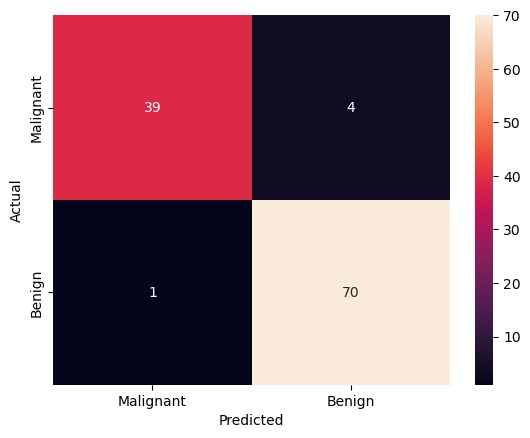

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
## Testing accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {accuracy * 100:.2f}%")

Testing Accuracy: 95.61%


Out of the 114 cancer samples that the model had not seen during training, it correctly classified approximately 95.61% of them.

Although 95.61% accuracy is very good, we shouldn't stop here. The confusion matrix shows that 4 malignant cases were classified as benign, so we need to examine precision, recall, and F1-score next. These metrics will tell us more about the model's performance for each class

In [27]:
## Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



MY NOTES:
The key metrics to remember are: **Accuracy** tells us how many predictions were correct overall, **Precision** tells us how often the model is correct when it predicts a particular class, **Recall** tells us how many of the actual cases in a class the model successfully identified, and **F1-score** provides a balance between precision and recall. For this particular dataset, **malignant recall is especially important at about 91%**, because the model missed **4 actual malignant cases by predicting them as benign**, which are the most important errors to discuss.


In [29]:
## Interpret the Logistic Regression coefficients
print(model.coef_)

[[ 0.978995  0.226653 -0.368592  0.026365 -0.155595 -0.228782 -0.523346
  -0.27988  -0.224217 -0.036102 -0.09502   1.389545 -0.16269  -0.089313
  -0.022549  0.050015 -0.040525 -0.031857 -0.033009  0.012028  0.092553
  -0.515646 -0.017131 -0.016513 -0.308068 -0.756819 -1.417241 -0.505079
  -0.738099 -0.099509]]


In [35]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": model.coef_[0]
})
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient,Odds_Ratio
11,texture error,1.389545,4.013024
0,mean radius,0.978995,2.661780
1,mean texture,0.226653,1.254394
20,worst radius,0.092553,1.096971
15,compactness error,0.050015,1.051287
3,mean area,0.026365,1.026716
19,fractal dimension error,0.012028,1.012101
23,worst area,-0.016513,0.983623
22,worst perimeter,-0.017131,0.983015
14,smoothness error,-0.022549,0.977704


The Logistic Regression model achieved a testing accuracy of 95.61%. The model demonstrated strong performance for both classes, with an F1-score of 0.94 for malignant cases and 0.97 for benign cases. The recall for malignant cases was 0.91, meaning that the model correctly identified approximately 91% of the malignant cases, while 4 malignant cases were incorrectly classified as benign. The recall for benign cases was 0.99, indicating that approximately 99% of benign cases were correctly identified. Overall, the model performed well, although its ability to detect malignant cases could be further improved.